In [3]:
import os 
import netCDF4 
import numpy as np
import xarray as xr
import pandas as pd
import warnings
from netCDF4 import Dataset,num2date
from datetime import datetime
warnings.filterwarnings("ignore")

In [4]:
def plot_time_series(var,vdat1,label1,vdat2,label2,year,exp):
   #start to plot data
   import cartopy.crs as ccrs
   import matplotlib.pyplot as plt
   import numpy as np
   import xarray as xr
   time  = vdat1.coords["time"]
   fontz = 16
   plt.rcParams.update({'font.size':fontz})
   f, ax = plt.subplots(1, 1, figsize=(12,6), sharey=True, layout='constrained')
   ax.plot(time, vdat1[var].data, label=label1, color='red',   linewidth=3, linestyle='-')  
   ax.plot(time, vdat2[var].data, label=label2, color='black', linewidth=3, linestyle='--')  
   ax.set_xlabel('Model Time')   # Add an x-label to the Axes.
   ax.set_ylabel('{} ({})'.format(vdat1.long_name,vdat1.units)) # Add a y-label to the Axes.
   ax.set_title("Time seires of {}".format(var))  # Add a title to the Axes.
   ax.legend()  # Add a legend.
   plt.show()
    
   #save figure 
   #figname = "time_series_{}_{}_{:04d}.png".format(exp,var,year)
   #plt.savefig(os.path.join("./diag_figure",figname))
   plt.close()

In [13]:
def plot_2d_hov(var,ds,year,exp): 
   #start to plot data
   import cartopy.crs as ccrs
   import matplotlib.pyplot as plt
   import numpy as np
   import xarray as xr
   dam = ds.groupby("time.month").mean("time")
   xvals = np.arange(len(ds[var][0,:]))
   vtim1 = ds.time.values.astype('datetime64[ms]').astype('O')
   vtim2 = dam.month.values.astype('O')
   #start to plot data
   #print(np.min(dam.data),np.max(dam.data))
   fontz = 16
   plt.rcParams.update({'font.size':fontz})
   clevs = np.linspace(np.min(dam[var]),np.max(dam[var]),11)
   fig, axs = plt.subplots(2,1, figsize=(10,12))
   #fig.suptitle('{}'.format(var_out))
   cntr0 = axs[0].contourf(xvals,vtim1, ds[var],   clevs,  cmap=plt.cm.jet)
   axs[0].set_title('3hourly Mean', loc='left', fontsize=fontz)
   axs[0].set_xlabel("Model columns (#)",fontsize=fontz)
   cntr1 = axs[1].contourf(xvals,vtim2, dam[var],  clevs,  cmap=plt.cm.jet)
   axs[1].set_title('3hourly to Monthly Mean', loc='left', fontsize=fontz)
   axs[1].set_xlabel("Model columns (#)", fontsize=fontz)
   axs[1].set_ylabel("Months", fontsize=fontz)
   plt.subplots_adjust(bottom=0.1, right = 0.8, hspace=0.3)  #, right=0.9, top=0.9)
   cbar_ax = fig.add_axes([0.82, 0.10, 0.02, 0.78]) #(left, bottom, width, height)
   cbar = fig.colorbar(cntr1, cax=cbar_ax, shrink=0.6, orientation='vertical',
                       pad=0.1, aspect=10, extendrect=True)
   cbar.set_label('{} ({})'.format(ds.long_name,ds.units),fontsize=fontz)
   plt.show()

   #figname = "hov_2d_{}_{}_{:04d}.png".format(exp,var,year)
   #plt.savefig(os.path.join("./diag_figure",figname))
   plt.close()
   del(vtim1,vtim2,xvals,ds,dam,clevs,fig,axs,cntr0,cntr1,cbar_ax,cbar)
   return

In [14]:
def plot_2d_map(varname,data,ymdh,exp,group,dsgrid):
   import time, os
   import xarray as xr
   import numpy as np
   import numpy.ma as ma
   import matplotlib as mpl
   import matplotlib.pyplot as plt
   import matplotlib.tri as tri
   from   matplotlib.collections import PolyCollection
   import cartopy.crs as ccrs
   import cartopy.feature as cfeature

   fontz = 16
   plt.rcParams.update({'font.size':fontz})

   #plt.switch_backend('agg')
   t1 = time.time()    #-- retrieve start time
   #only select first time step: 
   lon  = data.lon.data #    = ((data.lon.data - 180) % 360) - 180
   lat  = data.lat.data
   var  = np.array(data[varname].data)
   #-- get coordinates and (if not in degree) convert radians to degrees
   clon = dsgrid.grid_center_lon.values
   clat = dsgrid.grid_center_lat.values
   clon_vertices = dsgrid.grid_corner_lon.values
   clat_vertices = dsgrid.grid_corner_lat.values
   # sanity check to ensure data grid are consistent with the grid info 
   if np.max(np.abs(clon-lon)) > 1e-5 or np.max(np.abs(clat-lat)) > 1e-5:
     print("data grid is inconsistent with grid info")
     exit("ERROR in plot_2d_map")

   ncells, nv = clon_vertices.shape[0], clon_vertices.shape[1]
   #-- set contour levels, labels
   varMin, varMax, nlevs = np.min(var), np.max(var), 21
   levels = np.linspace(varMin,varMax,nlevs)
   if np.max(np.abs(levels)) < 1:
     xformat = '%0.2e'  
     labels = ['{:.2e}'.format(x) for x in levels]
   else:
     xformat = '%0.2f'  
     labels = ['{:.2f}'.format(x) for x in levels]
   #-- print information to stdout
   print('')
   print('Cells:            %6d ' % clon.size)
   print('Variable min/max: %6.2f ' % np.nanmin(var)+'/'+' %.2f' % np.nanmax(var))
   print('Contour  min/max: %6.2f ' % varMin+'/'+' %.2f' % varMax)
   print('')
   #-- set title string
   title = '{} from E3SMv2(NE30PG2 Grid)'.format(varname)
   #-- set projection
   projection = ccrs.PlateCarree()
   #-- create figure and axes instances; we need subplots for plot and colorbar
   fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(projection=projection))
   ax.set_global()
   #-- plot land areas at last to get rid of the contour lines at land
   ax.coastlines(linewidth=0.5, zorder=2)
   ax.gridlines(draw_labels=True, linewidth=0.5, color='dimgray', alpha=0.4,
                zorder=2)
   #-- plot the title string
   plt.title(title)
   #-- define color map
   cmap     = plt.get_cmap('Spectral_r', nlevs)        #-- read the color map
   cmaplist = [i for i in range(cmap.N)]               #-- color bar indices
   ncol     = len(cmaplist)                            #-- number of colors
   colors   = np.ones([ncells,4], np.float32)       #-- assign color array for triangles
   print('levels:      ',levels)
   print('nlevs:       %3d' %nlevs)
   print('ncol:        %3d' %ncol)
   print('')
   #-- set color index of all cells in between levels
   for m in range(0,ncol-1):
       vind = []
       for i in range(0,ncells-2, 1):
           if (var[i] >= levels[m] and var[i] < levels[m+1]):
              colors[i,:] = cmap(cmaplist[m])
              vind.append(i)
       print('set colors: finished level %3d' % m ,
             ' -- %5d ' % len(vind) ,
             ' polygons considered')
       del vind
   colors[np.where(var < varMin),:]  = cmap(cmaplist[0])
   colors[np.where(var >= varMax),:] = cmap(cmaplist[ncol-1])
   #-- plot the grid cells 
   clon_vertices = np.where(clon_vertices < -180., clon_vertices + 360., clon_vertices)
   clon_vertices = np.where(clon_vertices >  180., clon_vertices - 360., clon_vertices)
   triangles = np.zeros((ncells, nv, 2), np.float32)
   for i in range(0, ncells, 1):
       triangles[i,:,0] = np.array(clon_vertices[i,:])
       triangles[i,:,1] = np.array(clat_vertices[i,:])
   print('')
   print('--> triangles done')
   #-- create polygon/triangle collection
   coll = PolyCollection(triangles, array=None, fc=colors, edgecolors='black',
                         linewidth=0.05, transform=ccrs.Geodetic(), zorder=0)
   ax.add_collection(coll)
   print('--> polygon collection done')

   cbar_ax = fig.add_axes([0.13, 0.19, 0.78, 0.02]) #(bottom,right,width,height)
   cb      = plt.cm.ScalarMappable(cmap=cmap,
                 norm=plt.Normalize(vmin=varMin, vmax=varMax))
   cbar    = plt.colorbar(cb,cax=cbar_ax, 
                          orientation='horizontal',
                          ticks=levels,
                          boundaries=levels,
                          format=xformat,
                          shrink=0.8,
                          pad=0.04,
                          aspect=30,)
   #plt.setp(cbar.ax.get_xticklabels()[::2], visible=False)
   cbar.set_label('{}({})'.format(data.long_name,data.units))

   #-- maximize and save the PNG file
   figname = os.path.join("./diag_figure",
                          "map_2d_{}_{}_{:04d}.png".format(exp,varname,year)
                         )
   plt.show()
   #plt.savefig(figname, bbox_inches='tight',dpi=300)

   #-- get wallclock time
   t2 = time.time()
   print('Wallclock time:  %0.3f seconds' % (t2-t1))
   print('')
   return 

In [15]:
def triangulate(vertices, x="Longitude", y="Latitude"):
    from scipy.spatial import Delaunay
    """
    Generate a triangular mesh for the given x,y, z vertices, using Delaunay triangulation.
    For large n, typically results in about double the number of triangles as vertices.
    """
    triang = Delaunay(vertices[[x, y]].values)
    print('Given', len(vertices), "vertices, created", len(triang.simplices), 'triangles.')
    return pd.DataFrame(triang.simplices, columns=['v0', 'v1', 'v2'])

In [16]:
def get_var_info (var, grp):
   import json
   from pprint import pprint
   wkdir = "/global/cfs/cdirs/e3sm/www/zhan391/SEA_CROGS/New_Training"
   print(os.path.join(wkdir,'variable_dictionary.json'))
   var_dic = json.load(open(os.path.join(wkdir,'variable_dictionary.json'))) 
   print("----------------------")
   print("Inquire variable: ",var)
   pprint(var_dic[grp][var])
   print("----------------------")
   vunit = var_dic[grp][var]["units"]
   vname = var_dic[grp][var]["longname"]
   return vunit,vname 

In [17]:
def main(exp,year,tunit,datadir,outpath):
   var_scalar = ["area","time","latitude","longitude",
                 "ICEFRAC","OCNFRAC","LANDFRAC","COSSZA","PHIS"]
   var_state  = ["U","V","T","Q","PRESSURE","WD","WS","PS"]
   var_tend   = ["U_TEND","V_TEND","T_TEND","Q_TEND"]

   l_get_var_info = False
   if l_get_var_info:
     #get information for variables
     for var in var_scalar:
       get_var_info (var, "scalar")
     for var in var_state:
       get_var_info (var, "state")
     for var in var_tend:
       get_var_info (var, "tendency")

   #------------------
   # plot variable 
   #------------------

   #read information for time, latitude and longitude 
   ftim = os.path.join(datadir,"E3SMv2_Scalar","{}_3hourly_{}.npy".format("time",year))
   flat = os.path.join(datadir,"E3SMv2_Scalar","{}_3hourly_{}.npy".format("latitude",year))
   flon = os.path.join(datadir,"E3SMv2_Scalar","{}_3hourly_{}.npy".format("longitude",year))
   farg = os.path.join(datadir,"E3SMv2_Scalar","{}_3hourly_{}.npy".format("area",year))

   #read and decode them to real date
   time = np.load(ftim,allow_pickle=True)
   lat  = np.load(flat,allow_pickle=True)
   lon  = np.load(flon,allow_pickle=True)
   area = np.load(farg,allow_pickle=True)
   print("shape:", time.shape)
   print("shape:", lat.shape)
   print("shape:", lon.shape)
   print("shape:", area.shape)

   #tdate = num2date(time, tunit, calendar="noleap").astype('datetime64[ns]')
   group = "E3SMv2_Scalar"
   for var in ["ICEFRAC","OCNFRAC","LANDFRAC","COSSZA","PHIS"]:
     vunit,vname = get_var_info (var, "scalar")
     print("working on varible: ", vname )

     #read npy data and convert to xarray dataset structure
     fdat  = os.path.join(datadir,group,"{}_3hourly_{}.npy".format(var,year))
     ds = xr.Dataset(
             {var: (["time", "ncol"], np.load(fdat,allow_pickle=True)),
              },
             coords={"lon": (["ncol"], np.load(flon,allow_pickle=True)),
                     "lat": (["ncol"], np.load(flat,allow_pickle=True)),
                     "area": (["ncol"],np.load(farg,allow_pickle=True)),
                     "time":num2date(time,tunit, calendar="noleap"
                                     ).astype('datetime64[ns]'),
                     "reference_time": tunit,
                     },
             attrs = dict(long_name=vname,
                          units=vunit,
                          ),
             )

     print("plot 2d hovmoller diagram")
     plot_2d_hov(var,ds,year,group)

     print("plot 2d map distribution")
     fgrd = xr.open_dataset(os.path.join(datadir,"E3SMv2_grid_info","ne30pg2_scrip.nc"),decode_times=False)
     #select a time step to plot (first step as example below)
     data = ds.isel(time=0)
     ymdh = data.time.dt.strftime("%Y-%m-%d_%HZ").data
     plot_2d_map(var,data,ymdh,exp,group,fgrd)
     
     print("plot time series" ) 
     #resample data if needed, e.g. from 3-hourly to daily values
     ds = ds.resample(time="D").mean()
     
     #unweigted mean 
     var_mean = ds.mean(("ncol"),keep_attrs=True)
     #generate weights: 
     #option 1: use cosine of latitude
     #weights = np.cos(np.deg2rad(ds.lat))
     #weights.name = "weights"
     #option 2: use area in model output
     weights = ds.area 
     weights.name = "weights"
     #Weighted mean
     ds_weighted   = ds.weighted(weights)
     vwgt_mean = ds_weighted.mean(("ncol"),keep_attrs=True)
     #call function to process plots
     plot_time_series(var,var_mean,"unweighted",vwgt_mean,"weighted",year,exp)

   return

shape: (2920,)
shape: (21600,)
shape: (21600,)
shape: (21600,)
/global/cfs/cdirs/e3sm/www/zhan391/SEA_CROGS/New_Training/variable_dictionary.json
----------------------
Inquire variable:  ICEFRAC
{'Group': 'Scalar Field',
 'longname': 'fraction of grid cell covered by sea-ice',
 'period': '1-year',
 'postprocess': 'resampling from monthly output to 3hourly',
 'product': 'E3SMv2',
 'range': '[0,1]',
 'refname': 'time',
 'scenario': 'historical',
 'shape': '(2920,21600)',
 'template': 'E3SMv2/LANDFRAC_3hourly_2007.npy',
 'units': '1'}
----------------------
working on varible:  fraction of grid cell covered by sea-ice
plot 2d hovmoller diagram


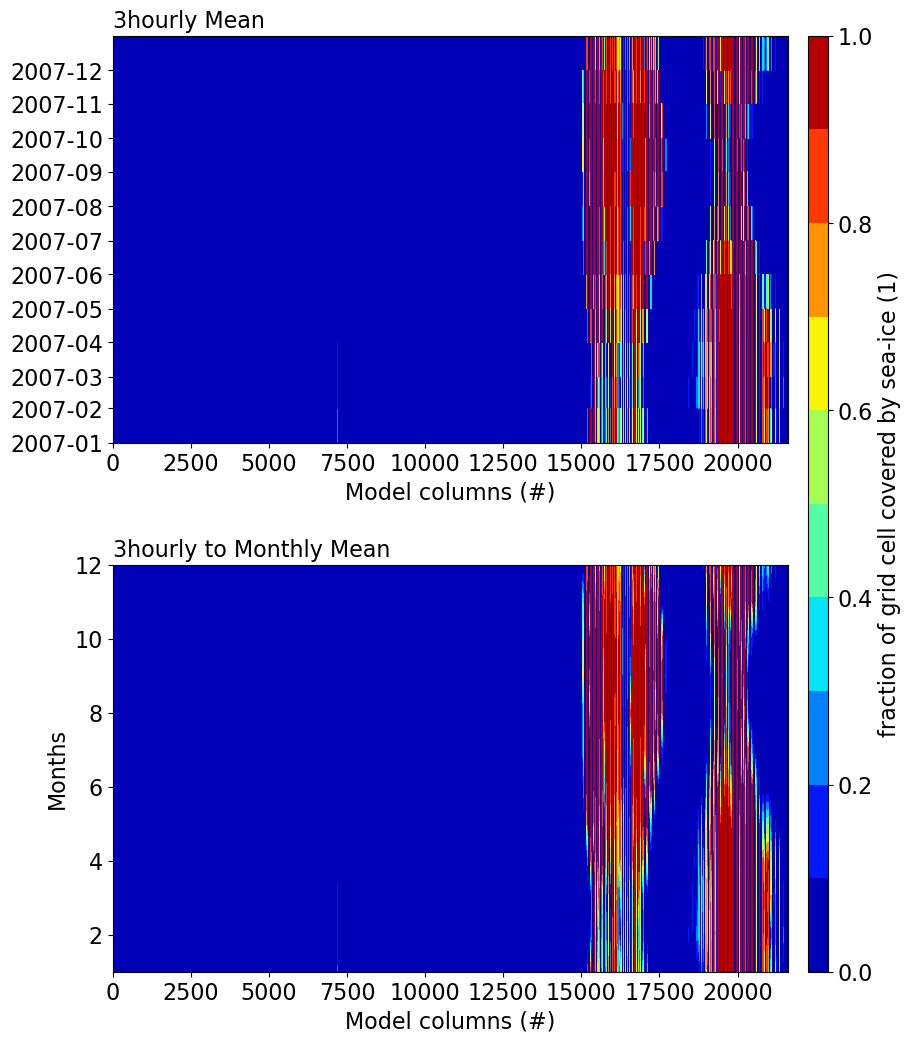

plot 2d map distribution

Cells:             21600 
Variable min/max:   0.00 / 1.00
Contour  min/max:   0.00 / 1.00

levels:       [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
nlevs:        21
ncol:         21

set colors: finished level   0  -- 20542   polygons considered
set colors: finished level   1  --   113   polygons considered
set colors: finished level   2  --    73   polygons considered
set colors: finished level   3  --    56   polygons considered
set colors: finished level   4  --    60   polygons considered
set colors: finished level   5  --    34   polygons considered
set colors: finished level   6  --    39   polygons considered
set colors: finished level   7  --    37   polygons considered
set colors: finished level   8  --    44   polygons considered
set colors: finished level   9  --    39   polygons considered
set colors: finished level  10  --    39   polygons considered
set colors: finished level  11  -

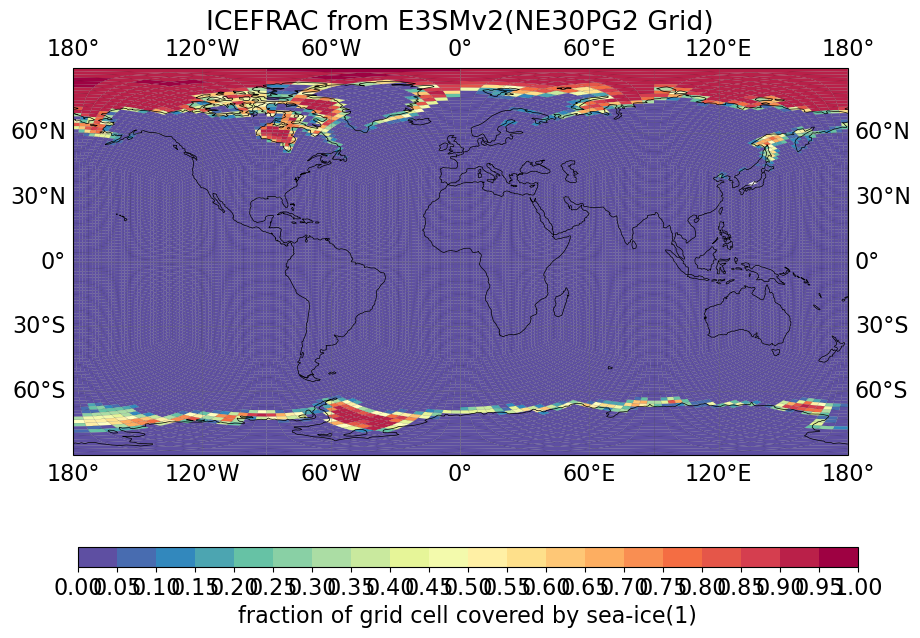

Wallclock time:  17.590 seconds

plot time series


FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/z/zhan391/SEACROGS_project/paper_material/training/diag_figure/time_series_E3SMv2_NDGUVTQ_SRF1_tau6_ICEFRAC_2007.png'

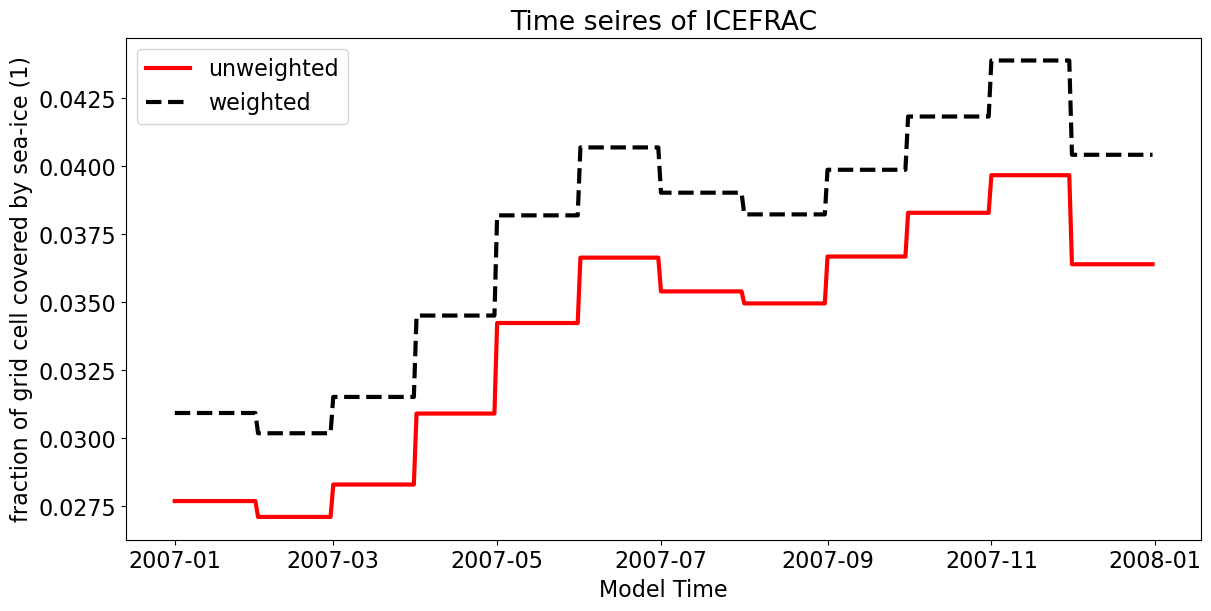

In [18]:
if __name__ == "__main__":

   datadir    = "/global/cfs/cdirs/e3sm/www/zhan391/SEA_CROGS/New_Training"
   exp        = "E3SMv2_NDGUVTQ_SRF1_tau6"
   time_unit  = "hours since 2007-01-01 00:00:00"
   
   #output path
   outpath    = "./"

   year = 2007
   main(exp,year,time_unit,datadir,outpath)